In [ ]:
!pip install langchain langgraph 

In [ ]:
!pip install dotenv

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
!pip install langchain-nvidia-ai-endpoints langchain-core langchain-community

In [1]:
from langgraph.graph import StateGraph,START,END,add_messages
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from typing import TypedDict,Annotated,List,Literal,operator
from langchain_core.messages import BaseMessage,HumanMessage,SystemMessage,AIMessage
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode,tools_condition
from pathlib import Path
import string
import os
import shutil

C:\Users\kiran\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model=ChatNVIDIA(model="meta/llama-3.1-70b-instruct")

In [ ]:
class StorageIntelligence(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
@tool
def list_drives() -> dict:
    """Return all available drives on the system."""

    result = []

    for letter in string.ascii_uppercase:
        drive = f"{letter}:/"
        if os.path.exists(drive):
            result.append(drive)

    return {"drives": result}


@tool
def get_drive_info() -> list[dict]:
    """Return storage information for all available drives."""

    result = []

    for letter in string.ascii_uppercase:
        drive = f"{letter}:/"
        if os.path.exists(drive):
            total, used, free = shutil.disk_usage(drive)

            result.append({
                "drive": drive,
                "total_gb": round(total / (1024**3), 2),
                "used_gb": round(used / (1024**3), 2),
                "free_gb": round(free / (1024**3), 2),
                "usage_percent": round((used / total) * 100, 2),
            })

    return result


@tool
def list_files_in_directory(path: str) -> dict:
    """
    List all folders and files in the given directory.
    Example paths:
    - C:/
    - D:/
    - C:/Users
    - D:/Movies
    """

    if not os.path.exists(path):
        return {"error": f"{path} does not exist."}

    if not os.path.isdir(path):
        return {"error": f"{path} is not a directory."}

    folders = []
    files = []

    try:
        for item in os.listdir(path):
            full_path = os.path.join(path, item)

            if os.path.isdir(full_path):
                folders.append(item)
            else:
                files.append(item)

        return {
            "path": path,
            "folders": folders,
            "files": files
        }

    except PermissionError:
        return {"error": f"Permission denied for {path}"}
    

@tool
def search_files(path: str, extension: str, limit: int = 100):
    """Search recursively for files."""

    results = []

    for root, _, files in os.walk(path):
        for file in files:
            if file.lower().endswith(extension.lower()):
                results.append(os.path.join(root, file))

                if len(results) >= limit:
                    return results

    return results

@tool
def search_by_filename(filename: str, path: str , limit: int = 100) -> dict:
    """
    Search for files by filename recursively.

    Examples:
    filename="resume.pdf"
    filename="resume"
    filename="python"
    """

    matches = []

    filename = filename.lower()

    for root, _, files in os.walk(path):
        try:
            for file in files:
                if filename in file.lower():      # Partial match
                    matches.append(os.path.join(root, file))

                    if len(matches) >= limit:
                        return {
                            "count": len(matches),
                            "results": matches,
                            "truncated": True
                        }

        except PermissionError:
            continue

    return {
        "count": len(matches),
        "results": matches,
        "truncated": False
    }


tools = [get_drive_info,list_files_in_directory,list_drives,search_files,search_by_filename]

llm = model.bind_tools(tools)


def get_drives(state: StorageIntelligence):
    response = llm.invoke(
        [SystemMessage(content='''You are an Intelligent Drive Explorer.
                                    Search files.

                                    The AI should choose the appropriate file_type.

                                    Categories:
                                    - image → jpg, jpeg, png, gif, bmp, webp, tiff, svg, ico
                                    - document → pdf, doc, docx, xls, xlsx, ppt, pptx, txt, csv
                                    - video → mp4, mkv, avi, mov, webm
                                    - audio → mp3, wav, flac, aac
                                    - python → py
                                    - archive → zip, rar, 7z, tar, gz
                                    - any → all files
                       ''')]
        + state["messages"]
    )

    return {
        "messages": [response]
    }


graph = StateGraph(StorageIntelligence)

graph.add_node("get_drive", get_drives)
graph.add_node("tools", ToolNode(tools))

graph.add_edge(START, "get_drive")

graph.add_conditional_edges(
    "get_drive",
    tools_condition,
)

graph.add_edge("tools", "get_drive")

app = graph.compile()

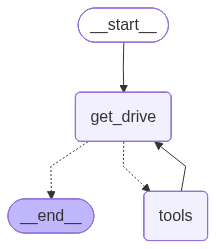

In [8]:
app

In [ ]:
result = app.invoke({
    "messages": [
        HumanMessage(content="Can you list the strictly Images files in the B drive?")
    ]
})

print(result["messages"][-1].content)